# <span style="color: #57A0D2"> Summary Statistics of an</span> <span style="color: #4D516D">IMDB Dataset </span>

### <span style="color: #4D516D">1. First 5 rows of the dataset</span>
df.head() is a method in pandas that returns the first 5 lines of the dataset by default, allowing the coder to quickly view the first rows of a dataset and inspect the structure, column names, etc.

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("imdb_top_1000.csv")
print(df.head())

   Rank                    Title                     Genre  \
0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1     2               Prometheus  Adventure,Mystery,Sci-Fi   
2     3                    Split           Horror,Thriller   
3     4                     Sing   Animation,Comedy,Family   
4     5            Suicide Squad  Action,Adventure,Fantasy   

                                         Description              Director  \
0  A group of intergalactic criminals are forced ...            James Gunn   
1  Following clues to the origin of mankind, a te...          Ridley Scott   
2  Three girls are kidnapped by a man with a diag...    M. Night Shyamalan   
3  In a city of humanoid animals, a hustling thea...  Christophe Lourdelet   
4  A secret government agency recruits some of th...            David Ayer   

                                              Actors  Year  Runtime (Minutes)  \
0  Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...  2014                121

### <span style="color: #4D516D">2. Data Structure</span>
df.info() is another method in pandas that generates a summary of the dataset's structure and content, including number of entries, column names, data types, and the count of non-null values in each columns. We would ideally like as few null values in our dataset as possible to ensure high quality in our dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


### <span style="color: #4D516D">3. Summary Statistics</span>
df.describe() is another method in pandas that computes statistical metrics for each NUMERICAL column, giving a more quantitative overview of the data's distribution and general tendencies. For example, this tells us that the data is concentrated in the 21st century with range 2006 to 2016 with movie length mostly in the 1.5 - 2 hour range. Based on the huge vote spread we could infer that a few movies are massively more popular than the rest of this list, meaning this is most likely a right-skewed distribution

In [33]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


### <span style="color: #4D516D">4. df.describe() full DataFrame</span>
The .describe() method summarizes only the numeric columns in the DataFrame, including Rank, Year, Runtime (Minutes), Rating, Votes, Revenue (Millions), and Metascore, while excluding non-numeric columns such as Title, Genre, and Director.

### <span style="color: #4D516D">5. Interpretation of numeric information</span>
- The mean of the Rating column represents the average movie rating in the dataset, giving a general sense of overall movie quality. 
- The standard deviation (std) shows how spread out the ratings are around the mean; a smaller value indicates that most movies have similar ratings, while a larger value suggests more variation.
- The minimum (min) value represents the lowest-rated movie in the dataset, showing the lower bound of ratings. 
- The 75% value (third quartile) indicates that 75% of the movies have ratings below this value, meaning only the top 25% of movies exceed it. 

These show that most movie ratings are clustered within a relatively narrow range, with a few higher-rated films pulling the mean upwards.

### <span style="color: #4D516D">6. Histogram of Runtime</span>

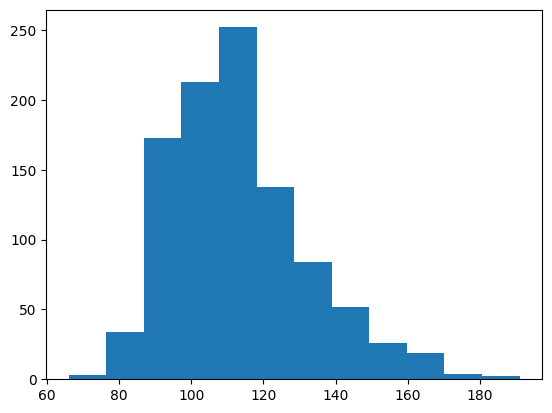

In [36]:
# df.hist(bins=10) would be an easy way to show all numeric columns if that was what you wanted
plt.hist(df["Runtime (Minutes)"], bins=12)
plt.show()

### <span style="color: #4D516D">7. Histogram Obervations</span>
The distribution of movie runtimes appears slightly right-skewed. Most films are clustered within the range of approximately 90 to 120 minutes, with the highest concentration around 100–110 minutes. There are fewer movies with very short runtimes (below 80 minutes) and a gradual tail extending toward longer runtimes (140+ minutes).
This indicates that while the majority of movies follow a standard feature-length duration, a smaller number of longer films skew the distribution to the right.

### <span style="color: #4D516D">8. Variance and Standard Deviation</span>
The variance of the IMDB_Rating column is approximately 0.894, and the standard deviation is approximately 0.945.
These values indicate that movie ratings are not very widely spread out from the mean. Since the standard deviation is less than 1, most ratings fall within about one point of the average rating. This suggests that IMDB ratings are relatively consistent, with most movies receiving similar scores and only a few deviating significantly higher or lower.

In [37]:
var = df['Rating'].var()
std = df['Rating'].std()
print(var)
print(std)

0.8938355955955956
0.9454287892779634


### <span style="color: #4D516D">9. Top 10 Highest rated movies</span>

In [42]:
top_10 = df.sort_values("Rating", ascending=False).head(10)
print(top_10[["Title", "Rating"]])

                Title  Rating
54    The Dark Knight     9.0
80          Inception     8.8
117            Dangal     8.8
36       Interstellar     8.6
96      Kimi no na wa     8.6
249  The Intouchables     8.6
133          Whiplash     8.5
64       The Prestige     8.5
99       The Departed     8.5
991  Taare Zameen Par     8.5


### <span style="color: #4D516D">10. Bottom 5 rated movies</span>

In [10]:
lowest_5 = df.sort_values("Rating", ascending=True).head(5)
print(lowest_5[["Title", "Rating"]])

                       Title  Rating
829           Disaster Movie     1.9
42   Don't Fuck in the Woods     2.7
871     Dragonball Evolution     2.7
647                 Tall Men     3.2
968                  Wrecker     3.5


### <span style="color: #4D516D">11. Movies rated above 8.5</span>

In [11]:
high_rated = df[df["Rating"] > 8.5]

print(high_rated[["Title", "Rating"]])  # show the movies
print("\nNumber of movies:", len(high_rated))  # count them

                Title  Rating
36       Interstellar     8.6
54    The Dark Knight     9.0
80          Inception     8.8
96      Kimi no na wa     8.6
117            Dangal     8.8
249  The Intouchables     8.6

Number of movies: 6


### <span style="color: #4D516D">12. Correlation Matrix</span>
One of the strongest relationships in the correlation matrix is between 'Rating' and 'Metascore' (about 0.63), which suggests that movies with higher IMDB ratings also tend to receive higher critic scores. 'Votes' also has a moderate positive correlation with 'Rating' (about 0.51), meaning more highly rated movies often receive more votes.

Another noticeable relationship is between 'Votes' and 'Revenue (Millions)' (about 0.64), suggesting that movies with more audience engagement tend to make more money. 'Runtime' has only a moderate positive correlation with 'Rating' and 'Votes', so longer movies are not necessarily much better, but they may be slightly more likely to be rated higher or receive more attention.

In [43]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                        Rank      Year  Runtime (Minutes)    Rating     Votes  \
Rank                1.000000 -0.261605          -0.221739 -0.219555 -0.283876   
Year               -0.261605  1.000000          -0.164900 -0.211219 -0.411904   
Runtime (Minutes)  -0.221739 -0.164900           1.000000  0.392214  0.407062   
Rating             -0.219555 -0.211219           0.392214  1.000000  0.511537   
Votes              -0.283876 -0.411904           0.407062  0.511537  1.000000   
Revenue (Millions) -0.271592 -0.126790           0.267953  0.217654  0.639661   
Metascore          -0.191869 -0.079305           0.211978  0.631897  0.325684   

                    Revenue (Millions)  Metascore  
Rank                         -0.271592  -0.191869  
Year                         -0.126790  -0.079305  
Runtime (Minutes)             0.267953   0.211978  
Rating                        0.217654   0.631897  
Votes                         0.639661   0.325684  
Revenue (Millions)            1.000000 

### <span style="color: #4D516D">13. Correlating with IMDB rating</span>
Positively correlated variables:
- Metascore (~0.63)
- Votes (~0.51)
- Runtime (Minutes) (~0.39)
- Revenue (Millions) (~0.22)

Negatively correlated variables:
- Year (~ -0.21)
- Rank (~ -0.22)

In [10]:
corr = df.corr(numeric_only=True)["Rating"].sort_values(ascending=False)
print(corr)

Rating                1.000000
Metascore             0.631897
Votes                 0.511537
Runtime (Minutes)     0.392214
Revenue (Millions)    0.217654
Year                 -0.211219
Rank                 -0.219555
Name: Rating, dtype: float64


### <span style="color: #4D516D">14. Filtering using multiple conditions</span>
Filtering for movies with Rating > 8.0 and Runtime < 100 minutes reveals a small group of films that are both highly rated and relatively short in length. These movies are worth achieved high audience approval without relying on long runtimes, which often allows for better storytelling. Shorter high-rated films may be more accessible to audiences, potentially increasing engagement while still maintaining quality. Studying these films could reveal patterns in genre, storytelling style, or structure that could contribute to their success.

In [13]:
filtered = df[(df["Rating"] > 8.0) & (df["Runtime (Minutes)"] < 100)]

print(filtered[["Title", "Rating", "Runtime (Minutes)"]])
print("\nNumber of movies:", len(filtered))

                              Title  Rating  Runtime (Minutes)
154  Twin Peaks: The Missing Pieces     8.1                 91
238        The Grand Budapest Hotel     8.1                 99
241                      Inside Out     8.2                 95
478                  Paint It Black     8.3                 96
499                              Up     8.3                 96
634                          WALL·E     8.4                 98
695             Hachi: A Dog's Tale     8.1                 93
772        How to Train Your Dragon     8.1                 98

Number of movies: 8


### <span style="color: #4D516D">15. IMBD rating boxplot</span>
The boxplot shows that most movie ratings are centered around approximately 6.5 to 7.0, with the median close to 6.7–6.8. The majority of ratings fall within a relatively narrow range (roughly 6.0 to 7.5), indicating that most top movies receive similar scores.
There are several noticeable outliers on the lower end, with ratings dropping below 5.0 and even as low as around 2.0–3.0.
There are no strong high-end outliers, so while some movies are highly rated, they are still within the expected range of the dataset

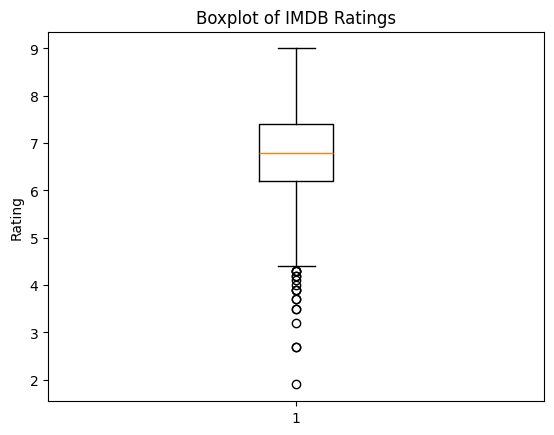

In [44]:
plt.boxplot(df["Rating"].dropna())
plt.title("Boxplot of IMDB Ratings")
plt.ylabel("Rating")

plt.show()

### <span style="color: #4D516D">16. Highest average rating by genre</span>

In [13]:
genre_avg = df.groupby("Genre")["Rating"].mean().sort_values(ascending=False)

print(genre_avg)
print("\nHighest average rating genre:", genre_avg.idxmax())

Genre
Animation,Drama,Fantasy    8.60
Drama,Family,Music         8.50
Drama,Western              8.40
Animation,Drama,Romance    8.40
Adventure,Drama,Sci-Fi     8.30
                           ... 
Action,Fantasy,Thriller    5.20
Sci-Fi,Thriller            5.00
Sci-Fi                     4.95
Comedy,Western             4.80
Fantasy,Horror,Thriller    3.20
Name: Rating, Length: 207, dtype: float64

Highest average rating genre: Animation,Drama,Fantasy


### <span style="color: #4D516D">17. Missing values and data cleaning</span>

In [45]:
print("Missing values per column:\n", df.isnull().sum())
df_clean = df.dropna()
print("\nRows remaining after dropping missing data:", len(df_clean))

Missing values per column:
 Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

Rows remaining after dropping missing data: 838


### <span style="color: #4D516D">18. Trend in average movie ratings over time</span>
The line chart shows that average movie ratings generally decline over time from 2006 to 2016. Ratings start slightly above 7.1 in the earlier years, fluctuate mildly between 6.8 and 7.0 for most of the period, and then drop more noticeably after 2014, reaching around 6.4 by 2016.
This suggests that more recent movies in the dataset tend to receive slightly lower average ratings compared to earlier years. While there are small fluctuations, the overall trend indicates a gradual decline in ratings over time.

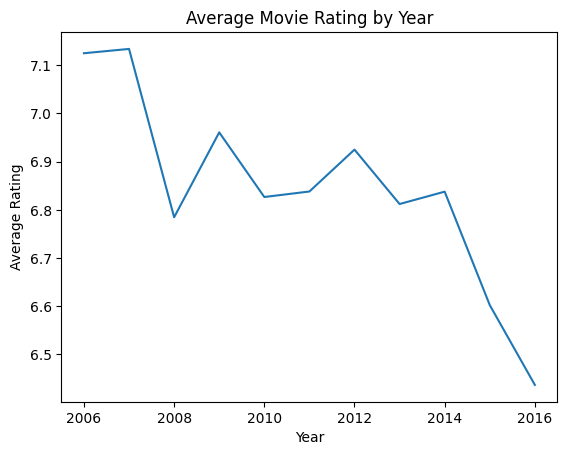

In [16]:
import matplotlib.pyplot as plt

year_avg = df.groupby("Year")["Rating"].mean()

plt.plot(year_avg.index, year_avg.values)
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Year")

plt.show()

### <span style="color: #4D516D">19. Movie certificates</span>
This dataset doesn't have a certificates column so it isn't possible to determine the most common movie certifications.

### <span style="color: #4D516D">20. Outliers in run time</span>
The mean runtime is approximately 113.17 minutes, with a standard deviation of about 18.81 minutes. Using the threshold of mean + 2 standard deviations (~150.8 minutes), several movies are identified as outliers with unusually long runtimes.
These include films such as The Wolf of Wall Street (180 min), The Hateful Eight (187 min), Interstellar (169 min), and multiple entries from The Dark Knight and Pirates of the Caribbean series.
Many of these films are also well-known, high-budget productions, indicating that longer runtimes may be associated with more ambitious or detailed narratives that could draw higher ratings.

In [20]:
mean_runtime = df["Runtime (Minutes)"].mean()
std_runtime = df["Runtime (Minutes)"].std()

outliers = df[df["Runtime (Minutes)"] > mean_runtime + 2 * std_runtime]

print("Mean runtime:", mean_runtime)
print("Std deviation:", std_runtime)
print("\nOutlier movies:\n")
print(outliers[["Title", "Runtime (Minutes)"]])

Mean runtime: 113.172
Std deviation: 18.810908172288393

Outlier movies:

                                                 Title  Runtime (Minutes)
26                             Bahubali: The Beginning                159
36                                        Interstellar                169
54                                     The Dark Knight                152
55                                             Silence                161
60                  Batman v Superman: Dawn of Justice                151
75            Pirates of the Caribbean: At World's End                169
77                                Inglourious Basterds                153
78          Pirates of the Caribbean: Dead Man's Chest                151
82                             The Wolf of Wall Street                180
87                                              Avatar                162
88                                   The Hateful Eight                187
90                                    

### <span style="color: #4D516D">21. Most voted movies per genre</span>

In [46]:
most_voted = df.loc[df.groupby("Genre")["Votes"].idxmax()]
print(most_voted[["Genre", "Title", "Votes"]])

top_genre = most_voted.loc[most_voted["Votes"].idxmax()]
print("\nGenre with highest voted movie:", top_genre["Genre"])

                          Genre                    Title   Votes
123                      Action     Boyka: Undisputed IV   10428
368            Action,Adventure   The Amazing Spider-Man  474320
558  Action,Adventure,Biography  In the Heart of the Sea   90372
33      Action,Adventure,Comedy                 Deadpool  627797
281      Action,Adventure,Crime          Sherlock Holmes  501769
..                          ...                      ...     ...
706     Romance,Sci-Fi,Thriller    The Adjustment Bureau  208632
183                      Sci-Fi                  Realive    1176
512             Sci-Fi,Thriller            The Happening  170897
282                    Thriller              Death Proof  220236
160                Thriller,War                     Mine    5926

[207 rows x 3 columns]

Genre with highest voted movie: Action,Crime,Drama


### <span style="color: #4D516D">Convert Runtime from string to integer</span>
As shown the dataset already stores runtime as numeric values in the "Runtime (Minutes)" column, so no conversion using .str.replace() or .astype() is required.

In [18]:
print(df.dtypes)

Rank                    int64
Title                  object
Genre                  object
Description            object
Director               object
Actors                 object
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object


### <span style="color: #4D516D">Grouping by genre</span>

In [21]:
# "Certificate" column doesn't exist in this dataset, however this is an example of grouping by genre
df.groupby("Genre")["Rating"].agg(["mean", "median", "std"])

,mean,median,std
Genre,,,
Action,6.150000,6.15,1.767767
"Action,Adventure",6.400000,6.20,0.529150
"Action,Adventure,Biography",7.000000,7.00,0.141421
"Action,Adventure,Comedy",6.592857,6.60,0.769080
"Action,Adventure,Crime",6.433333,6.15,0.900370
...,...,...,...
"Romance,Sci-Fi,Thriller",7.100000,7.10,NaN
Sci-Fi,4.950000,4.95,1.343503
"Sci-Fi,Thriller",5.000000,5.00,NaN


### <span style="color: #4D516D">Sorting by Rating and Votes</span>

In [22]:
sorted_df = df.sort_values(by=["Rating", "Votes"], ascending=[False, False])

print(sorted_df[["Title", "Rating", "Votes"]].head())

                Title  Rating    Votes
54    The Dark Knight     9.0  1791916
80          Inception     8.8  1583625
117            Dangal     8.8    48969
36       Interstellar     8.6  1047747
249  The Intouchables     8.6   557965


### <span style="color: #4D516D">Cleaning Gross Colomn</span>
The dataset does not contain a "Gross" column. Revenue is already stored numerically in "Revenue (Millions)", so no cleaning is required. If it did require cleaning, it would involve removing commas and currency symbols using .str.replace() and converting to float with .astype(), then filling missing values with the median using .fillna().

In [23]:
print(df["Revenue (Millions)"].dtype)

float64


### <span style="color: #4D516D">Movie length categories</span>

In [25]:
df["Movie_Length"] = pd.cut(
    df["Runtime (Minutes)"],
    bins=[0, 90, 150, 500],
    labels=["Short", "Standard", "Epic"]
)

print(df[["Title", "Runtime (Minutes)", "Movie_Length"]].head())

                     Title  Runtime (Minutes) Movie_Length
0  Guardians of the Galaxy                121     Standard
1               Prometheus                124     Standard
2                    Split                117     Standard
3                     Sing                108     Standard
4            Suicide Squad                123     Standard


### <span style="color: #4D516D">Genre Filtering</span>

In [47]:
filtered = df[
    df["Genre"].str.contains("Action") |
    df["Genre"].str.contains("Drama") |
    df["Genre"].str.contains("Comedy")
]

print(filtered[["Title", "Genre"]])

                       Title                     Genre
0    Guardians of the Galaxy   Action,Adventure,Sci-Fi
3                       Sing   Animation,Comedy,Family
4              Suicide Squad  Action,Adventure,Fantasy
5             The Great Wall  Action,Adventure,Fantasy
6                 La La Land        Comedy,Drama,Music
..                       ...                       ...
994                Project X                    Comedy
995     Secret in Their Eyes       Crime,Drama,Mystery
997   Step Up 2: The Streets       Drama,Music,Romance
998             Search Party          Adventure,Comedy
999               Nine Lives     Comedy,Family,Fantasy

[879 rows x 2 columns]


### <span style="color: #4D516D">Top movies each year</span>

In [27]:
idx = df.groupby("Year")["Rating"].idxmax()

top_movies_each_year = df.loc[idx]

print(top_movies_each_year[["Year", "Title", "Rating"]])

     Year                    Title  Rating
64   2006             The Prestige     8.5
991  2007         Taare Zameen Par     8.5
54   2008          The Dark Knight     9.0
430  2009                 3 Idiots     8.4
80   2010                Inception     8.8
249  2011         The Intouchables     8.6
124  2012    The Dark Knight Rises     8.5
82   2013  The Wolf of Wall Street     8.2
36   2014             Interstellar     8.6
26   2015  Bahubali: The Beginning     8.3
117  2016                   Dangal     8.8


### <span style="color: #4D516D">Genre filtering with lists</span>

In [28]:
df["Genre"] = df["Genre"].str.split(", ")

df_exploded = df.explode("Genre")

print(df_exploded[["Title", "Genre"]].head(10))

                     Title                       Genre
0  Guardians of the Galaxy     Action,Adventure,Sci-Fi
1               Prometheus    Adventure,Mystery,Sci-Fi
2                    Split             Horror,Thriller
3                     Sing     Animation,Comedy,Family
4            Suicide Squad    Action,Adventure,Fantasy
5           The Great Wall    Action,Adventure,Fantasy
6               La La Land          Comedy,Drama,Music
7                 Mindhorn                      Comedy
8       The Lost City of Z  Action,Adventure,Biography
9               Passengers     Adventure,Drama,Romance


### <span style="color: #4D516D">Filtering with rating and votes</span>

In [29]:
filtered = df.query("Rating > 8.0 and Votes > 100000")

print(filtered[["Title", "Rating", "Votes"]])
print(len(filtered))

                                            Title  Rating    Votes
0                         Guardians of the Galaxy     8.1   757074
6                                      La La Land     8.3   258682
16                                  Hacksaw Ridge     8.2   211760
18                                           Lion     8.1   102061
36                                   Interstellar     8.6  1047747
50     Star Wars: Episode VII - The Force Awakens     8.1   661608
54                                The Dark Knight     9.0  1791916
64                                   The Prestige     8.5   913152
67                             Mad Max: Fury Road     8.1   632842
74                                       Zootopia     8.1   296853
76                                   The Avengers     8.1  1045588
77                           Inglourious Basterds     8.3   959065
80                                      Inception     8.8  1583625
82                        The Wolf of Wall Street     8.2   86

### <span style="color: #4D516D">Top 5 longest movies by runtime</span>
The dataset does not contain a "Certificate" column, so it is not possible to filter for movies rated 'R'. However, using .nlargest(), the top 5 longest movies can be identified based on runtime.

In [30]:
top_5_longest = df.nlargest(5, "Runtime (Minutes)")
print(top_5_longest[["Title", "Runtime (Minutes)"]])

                       Title  Runtime (Minutes)
828               Grindhouse                191
88         The Hateful Eight                187
82   The Wolf of Wall Street                180
311           La vie d'Adèle                180
965            Inland Empire                180
